In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import glob
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
pnemonic_path=r"C:\Users\ksri0\Downloads\archive (14)\chest_xray\chest_xray\test\PNEUMONIA"
normal_path=r"C:\Users\ksri0\Downloads\archive (14)\chest_xray\chest_xray\test\NORMAL"

In [10]:
IMG_SIZE=(150,150)
BATCH_SIZE=32

In [11]:
pnemonic_images=glob.glob(pnemonic_path + r"\*.jpeg")
print("Number of pnemonic images: ",len(pnemonic_images))
normal_images=glob.glob(normal_path + r"\*.jpeg")
print("Number of normal images: ",len(normal_images))

Number of pnemonic images:  390
Number of normal images:  234


In [12]:
pnemonic_df=pd.DataFrame({"filename": pnemonic_images,"label":1})
normal_df=pd.DataFrame({"filename": normal_images,"label":0})
df=pd.concat([pnemonic_df,normal_df],ignore_index=True)

In [13]:
print("\n Dataset Shape: ")
print(df.shape)
print("\n First 5 Records: ")
print(df.head())
print("\n Last 5 Records: ")
print(df.tail())
print("\n Missing values: ")
print(df.isnull().sum())
print("\n Duplicates: ")
print(df.duplicated().sum())
df=df.drop_duplicates()


 Dataset Shape: 
(624, 2)

 First 5 Records: 
                                            filename  label
0  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      1
1  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      1
2  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      1
3  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      1
4  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      1

 Last 5 Records: 
                                              filename  label
619  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      0
620  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      0
621  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      0
622  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      0
623  C:\Users\ksri0\Downloads\archive (14)\chest_xr...      0

 Missing values: 
filename    0
label       0
dtype: int64

 Duplicates: 
0


In [14]:
print("\n Class Distribution: ")
print(df["label"].value_counts())
print("\n Class Names:")
print(df["label"].value_counts().rename(index={0: "Normal", 1: "PNEUMONIA"}))


 Class Distribution: 
label
1    390
0    234
Name: count, dtype: int64

 Class Names:
label
PNEUMONIA    390
Normal       234
Name: count, dtype: int64


In [15]:
df = df.sample(frac=1,random_state=42
).reset_index(drop=True)

train_df, test_df = train_test_split(df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"])

print("\nTraining Images:",len(train_df))
print("Testing Images:",len(test_df))


Training Images: 499
Testing Images: 125


In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.20)

In [17]:
test_datagen = ImageDataGenerator(
    rescale=1./255)

In [18]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="training",
    shuffle=True)

Found 400 validated image filenames.


In [19]:
validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="validation",
    shuffle=False)

Found 99 validated image filenames.


In [20]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False)


print("\nTraining Samples:",train_generator.samples)
print("Validation Samples:",validation_generator.samples)
print("Testing Samples:",test_generator.samples)

Found 125 validated image filenames.

Training Samples: 400
Validation Samples: 99
Testing Samples: 125


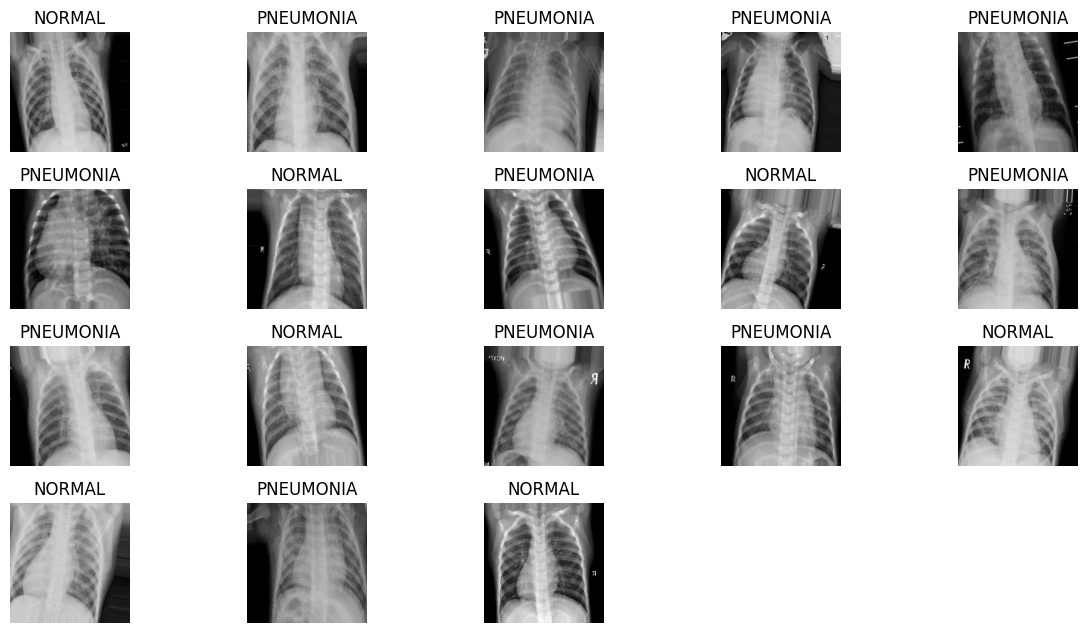

In [23]:
images , labels=next(train_generator)
plt.figure(figsize=(12,8))
for i in range(18):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    if labels[i]==1:
        plt.title("PNEUMONIA")
    else:
        plt.title("NORMAL")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [24]:
model = Sequential([

Conv2D(32,(3,3),activation="relu",
       input_shape=(150,150,3)),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation="relu"),
MaxPooling2D(2,2),

Conv2D(128,(3,3),activation="relu"),
MaxPooling2D(2,2),

Flatten(),

Dense(256,activation="relu"),

Dropout(0.5),
Dense(1,activation='sigmoid')])

In [25]:
from tensorflow.keras.optimizers import Adam

model.summary()

model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       9,470,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,563,713 (36.48 MB)

 Trainable params: 9,563,713 (36.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(train_generator,
                 validation_data=validation_generator,
                 epochs=10)
test_loss, test_accuracy=model.evaluate(test_generator)
print("TEST RESULTS")
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)

Epoch 1/10
 8/13 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6016 - loss: 0.7515

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()